# 06 — Random Forest Forecasting

Complete standalone Random Forest regression notebook for the UAC Forecasting Project.

This notebook:
- loads processed_data.csv from the project's nested folder structure
- creates time-series lag and rolling features
- performs a chronological train/test split
- trains RandomForestRegressor
- evaluates MAE, RMSE and MAPE
- plots actual vs predicted values
- shows feature importance
- saves predictions and metrics


In [52]:
# 1. Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("✅ Imports successful")


✅ Imports successful


In [53]:
# 2. Load and clean the processed dataset

data_candidates = [
    Path("data/processed_data.csv"),
    Path("UAC_Forecasting_Project/data/processed_data.csv"),
]

data_path = next(
    (p for p in data_candidates if p.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        "processed_data.csv was not found.\n"
        + "\n".join(str(p) for p in data_candidates)
        + f"\n\nCurrent working directory: {Path.cwd()}"
    )

df = pd.read_csv(data_path)

print("📁 Loaded:", data_path)
print("📊 Original shape:", df.shape)

target = "Children in HHS Care"

if "Date" not in df.columns:
    raise ValueError("The dataset does not contain a 'Date' column.")

if target not in df.columns:
    raise ValueError(f"The dataset does not contain '{target}'.")

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df[target] = (
    df[target]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

df[target] = pd.to_numeric(
    df[target],
    errors="coerce"
)

df = df.dropna(
    subset=["Date", target]
).copy()

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna(
    subset=[target]
)

df = df.sort_values("Date")

# Aggregate duplicate dates
df = (
    df.groupby("Date", as_index=False)[target]
    .mean()
)

print("✅ Cleaned shape:", df.shape)
display(df.head())


📁 Loaded: UAC_Forecasting_Project\data\processed_data.csv
📊 Original shape: (1170, 14)
✅ Cleaned shape: (720, 2)


,Date,Children in HHS Care
0,2023-01-12,6566.0
1,2023-01-22,7122.0
2,2023-01-23,7280.0
3,2023-01-24,7433.0
4,2023-01-25,7538.0


In [54]:
# 3. Create Random Forest time-series features

# Sort first
df = df.sort_values("Date").reset_index(drop=True)

# Calendar features
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["dayofweek"] = df["Date"].dt.dayofweek
df["dayofyear"] = df["Date"].dt.dayofyear

# Lag features
df["lag1"] = df[target].shift(1)
df["lag2"] = df[target].shift(2)
df["lag3"] = df[target].shift(3)
df["lag7"] = df[target].shift(7)
df["lag14"] = df[target].shift(14)
df["lag30"] = df[target].shift(30)

# Rolling features — shifted first to prevent using the current target
df["rolling_mean_7"] = (
    df[target]
    .shift(1)
    .rolling(7)
    .mean()
)

df["rolling_mean_14"] = (
    df[target]
    .shift(1)
    .rolling(14)
    .mean()
)

df["rolling_std_7"] = (
    df[target]
    .shift(1)
    .rolling(7)
    .std()
)

# Remove rows created by lag/rolling operations
df_model = df.dropna().reset_index(drop=True)

print("✅ Feature engineering complete")
print("Modeling rows:", len(df_model))

display(df_model.head())


✅ Feature engineering complete
Modeling rows: 690


,Date,Children in HHS Care,year,month,quarter,dayofweek,dayofyear,lag1,lag2,lag3,lag7,lag14,lag30,rolling_mean_7,rolling_mean_14,rolling_std_7
0,2023-03-08,7885.0,2023,3,1,2,67,7859.0,7870.0,7930.0,7914.0,7483.0,6566.0,7839.714286,7827.071429,110.252308
1,2023-03-09,7786.0,2023,3,1,3,68,7885.0,7859.0,7870.0,7609.0,7794.0,7122.0,7835.571429,7855.785714,107.506367
2,2023-03-13,7567.0,2023,3,1,0,72,7786.0,7885.0,7859.0,7800.0,7869.0,7280.0,7860.857143,7855.214286,51.628250
3,2023-03-14,7810.0,2023,3,1,1,73,7567.0,7786.0,7885.0,7896.0,7793.0,7433.0,7827.571429,7833.642857,123.075664
4,2023-03-15,7915.0,2023,3,1,2,74,7810.0,7567.0,7786.0,7930.0,7817.0,7538.0,7815.285714,7834.857143,119.342245


In [55]:
# 4. Prepare X and y

feature_columns = [
    "year",
    "month",
    "quarter",
    "dayofweek",
    "dayofyear",
    "lag1",
    "lag2",
    "lag3",
    "lag7",
    "lag14",
    "lag30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7",
]

X = df_model[feature_columns].copy()
y = df_model[target].copy()

# Ensure all features are numeric
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

valid_rows = (
    X.notna().all(axis=1)
    & y.notna()
    & np.isfinite(X).all(axis=1)
    & np.isfinite(y)
)

X = X.loc[valid_rows].reset_index(drop=True)
y = y.loc[valid_rows].reset_index(drop=True)

model_dates = df_model.loc[
    valid_rows,
    "Date"
].reset_index(drop=True)

print("Features:", X.shape)
print("Target:", y.shape)
print("Feature columns:")
print(feature_columns)


Features: (690, 14)
Target: (690,)
Feature columns:
['year', 'month', 'quarter', 'dayofweek', 'dayofyear', 'lag1', 'lag2', 'lag3', 'lag7', 'lag14', 'lag30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7']


In [56]:
# 5. Chronological train/test split

if len(X) < 20:
    raise ValueError(
        f"Only {len(X)} usable modeling rows are available. "
        "At least 20 are recommended."
    )

split_index = int(len(X) * 0.80)
split_index = max(1, min(split_index, len(X) - 1))

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

dates_train = model_dates.iloc[:split_index]
dates_test = model_dates.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

print("\nTraining period:")
print(dates_train.min(), "→", dates_train.max())

print("\nTesting period:")
print(dates_test.min(), "→", dates_test.max())


Training rows: 552
Testing rows : 138

Training period:
2023-03-08 00:00:00 → 2025-05-22 00:00:00

Testing period:
2025-05-27 00:00:00 → 2025-12-21 00:00:00


In [57]:
# 6. Train Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("✅ Random Forest model trained successfully")
print("Number of trees:", rf_model.n_estimators)


✅ Random Forest model trained successfully
Number of trees: 300


In [58]:
import joblib
from pathlib import Path

# ------------------------------------------------------------
# SAVE TRAINED RANDOM FOREST
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

# If Jupyter is running inside notebooks/
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "best_model.pkl"

joblib.dump(rf_model, MODEL_PATH)

print("============================================")
print("✅ MODEL SAVED SUCCESSFULLY")
print("============================================")
print("Location:", MODEL_PATH.resolve())
print("Size:", MODEL_PATH.stat().st_size, "bytes")
print("Model:", type(rf_model).__name__)
print("Trees:", rf_model.n_estimators)

✅ MODEL SAVED SUCCESSFULLY
Location: C:\Users\kapta\Downloads\UAC-Forecasting-Project-main\UAC-Forecasting-Project-main\models\best_model.pkl
Size: 14704833 bytes
Model: RandomForestRegressor
Trees: 300


In [44]:
# 7. Predict on the test set

predictions = rf_model.predict(X_test)

predictions = np.asarray(
    predictions,
    dtype=float
)

print("Predictions:", len(predictions))
print("NaN predictions:", np.isnan(predictions).sum())
print("Infinite predictions:", np.isinf(predictions).sum())

if not np.isfinite(predictions).all():
    raise ValueError(
        "Random Forest produced invalid predictions."
    )


Predictions: 138
NaN predictions: 0
Infinite predictions: 0


In [45]:
# 8. Evaluate the model

evaluation = pd.DataFrame({
    "Date": dates_test.to_numpy(),
    "Actual": y_test.to_numpy(),
    "Predicted": predictions
})

evaluation = evaluation.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

if evaluation.empty:
    raise ValueError(
        "No valid actual/predicted pairs are available."
    )

actual = evaluation["Actual"].astype(float)
predicted = evaluation["Predicted"].astype(float)

mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

nonzero = actual != 0

if nonzero.any():
    mape = (
        np.mean(
            np.abs(
                (actual[nonzero] - predicted[nonzero])
                / actual[nonzero]
            )
        ) * 100
    )
else:
    mape = np.nan

print("=" * 55)
print("RANDOM FOREST RESULTS")
print("=" * 55)
print(f"Valid observations: {len(evaluation)}")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print("=" * 55)


RANDOM FOREST RESULTS
Valid observations: 138
MAE : 62.93
RMSE: 85.56
MAPE: 2.98%


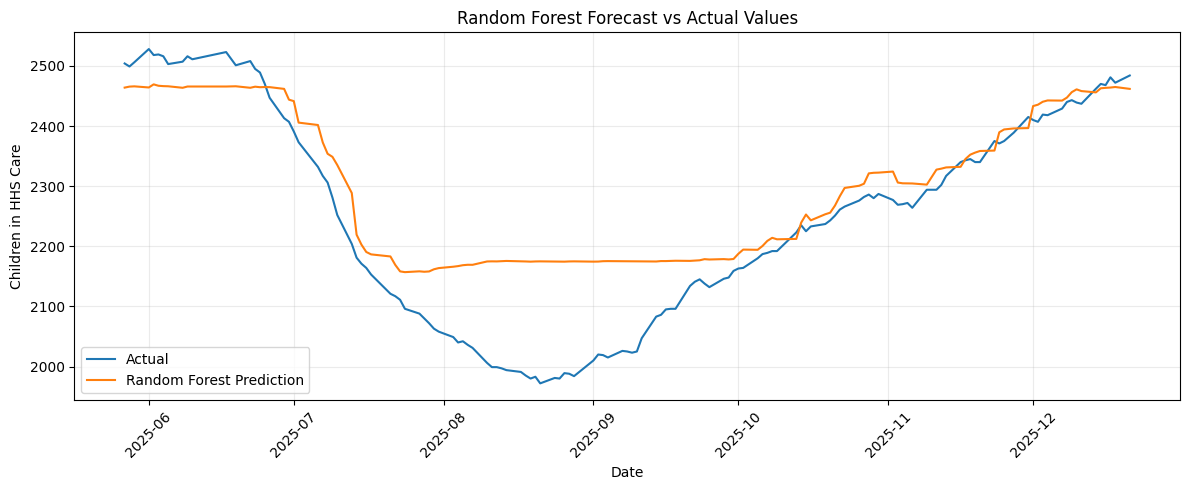

In [46]:
# 9. Plot actual vs predicted values

plt.figure(figsize=(12, 5))

plt.plot(
    evaluation["Date"],
    evaluation["Actual"],
    label="Actual"
)

plt.plot(
    evaluation["Date"],
    evaluation["Predicted"],
    label="Random Forest Prediction"
)

plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.title("Random Forest Forecast vs Actual Values")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


,Feature,Importance
5,lag1,0.674303
6,lag2,0.152221
11,rolling_mean_7,0.064648
7,lag3,0.054894
8,lag7,0.023631
12,rolling_mean_14,0.020241
9,lag14,0.005246
4,dayofyear,0.003050
1,month,0.000534
3,dayofweek,0.000439


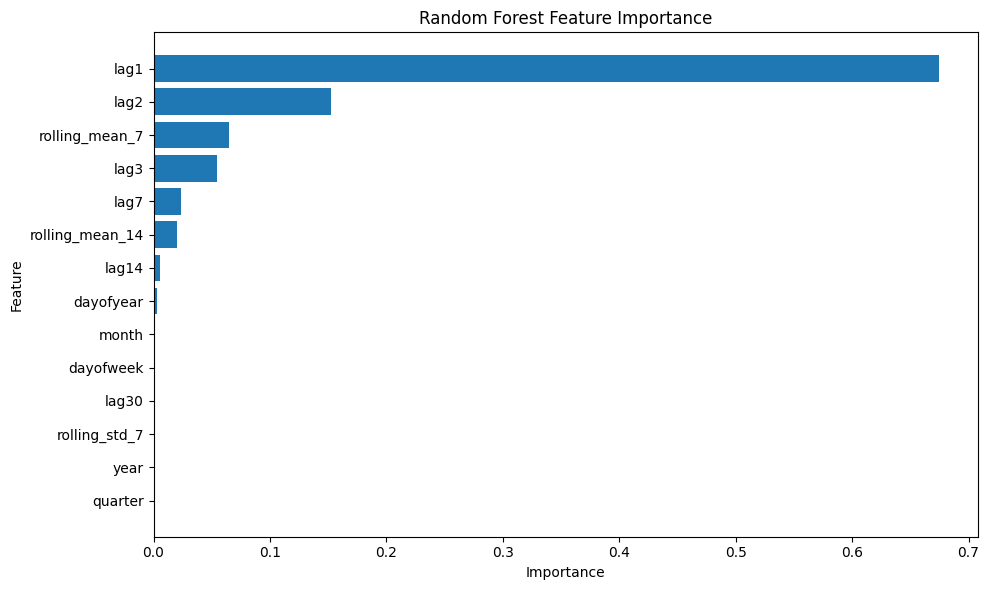

In [47]:
# 10. Feature importance

importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"][::-1],
    importance["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()


In [48]:
# 11. Save predictions and metrics

output_candidates = [
    Path("data"),
    Path("UAC_Forecasting_Project/data")
]

output_dir = next(
    (p for p in output_candidates if p.exists()),
    None
)

if output_dir is None:
    raise FileNotFoundError(
        "Could not find the project data directory. "
        f"Current directory: {Path.cwd()}"
    )

predictions_path = (
    output_dir / "random_forest_predictions.csv"
)

evaluation.to_csv(
    predictions_path,
    index=False
)

metrics = pd.DataFrame([{
    "Model": "Random Forest",
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape
}])

metrics_path = (
    output_dir / "random_forest_metrics.csv"
)

metrics.to_csv(
    metrics_path,
    index=False
)

importance_path = (
    output_dir / "random_forest_feature_importance.csv"
)

importance.to_csv(
    importance_path,
    index=False
)

print("✅ Predictions saved to:")
print(predictions_path.resolve())

print("\n✅ Metrics saved to:")
print(metrics_path.resolve())

print("\n✅ Feature importance saved to:")
print(importance_path.resolve())


✅ Predictions saved to:
C:\Users\kapta\Downloads\UAC-Forecasting-Project-main\UAC-Forecasting-Project-main\UAC_Forecasting_Project\data\random_forest_predictions.csv

✅ Metrics saved to:
C:\Users\kapta\Downloads\UAC-Forecasting-Project-main\UAC-Forecasting-Project-main\UAC_Forecasting_Project\data\random_forest_metrics.csv

✅ Feature importance saved to:
C:\Users\kapta\Downloads\UAC-Forecasting-Project-main\UAC-Forecasting-Project-main\UAC_Forecasting_Project\data\random_forest_feature_importance.csv


In [49]:
# 12. Final summary

print("🎯 Random Forest training complete!")
print()
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print()
print("Top 5 features:")

display(
    importance.head(5)
)


🎯 Random Forest training complete!

MAE  : 62.93
RMSE : 85.56
MAPE : 2.98%

Top 5 features:


,Feature,Importance
5,lag1,0.674303
6,lag2,0.152221
11,rolling_mean_7,0.064648
7,lag3,0.054894
8,lag7,0.023631
